<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/LogosticRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ロジスティック回帰

## 基本的な訓練と評価

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ─────────────────────────
# データの準備
# ─────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

# 訓練データとテストデータに分割（7:3）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 特徴量のスケーリング（ロジスティック回帰では推奨）
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ─────────────────────────
# モデルの構築と学習
# ─────────────────────────
model = LogisticRegression(
    C=1.0,                    # 正則化の強さの逆数（大きいほど正則化が弱い）
    penalty='l2',             # 正則化の種類（'l1', 'l2', 'elasticnet', None）
    solver='lbfgs',           # 最適化アルゴリズム
    max_iter=200,             # 最大反復回数
    random_state=42
)
model.fit(X_train_sc, y_train)

# ─────────────────────────
# 予測と評価
# ─────────────────────────
y_pred = model.predict(X_test_sc)

print(f"正解率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(
    y_test, y_pred, target_names=iris.target_names
))


正解率 (Accuracy): 0.9111

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## 確率出力の確認

In [3]:
# 各クラスに属する確率を取得
y_prob = model.predict_proba(X_test_sc)

# テストデータの先頭 5 件について確率を表示
print("サンプル  |  setosa   versicolor  virginica  | 予測")
print("-" * 58)
for i in range(5):
    probs = y_prob[i]
    pred = iris.target_names[y_pred[i]]
    print(f"  {i:3d}     | {probs[0]:.4f}    {probs[1]:.4f}     {probs[2]:.4f}   | {pred}")

サンプル  |  setosa   versicolor  virginica  | 予測
----------------------------------------------------------
    0     | 0.0000    0.1014     0.8985   | virginica
    1     | 0.0141    0.7894     0.1964   | versicolor
    2     | 0.0036    0.6202     0.3762   | versicolor
    3     | 0.0218    0.6292     0.3490   | versicolor
    4     | 0.0052    0.3846     0.6103   | virginica


## 学習されたパラメータの確認

In [4]:
# 重み（係数）の確認
print("=== 学習された重み（各クラス × 各特徴量） ===\n")
for i, class_name in enumerate(iris.target_names):
    print(f"[{class_name}]")
    for j, feat_name in enumerate(iris.feature_names):
        print(f"  {feat_name:20s}: {model.coef_[i][j]:+.4f}")
    print(f"  {'バイアス (intercept)':20s}: {model.intercept_[i]:+.4f}")
    print()

# 解釈の例
# 正の重みが大きい特徴量ほど，そのクラスに属する確率を高める


=== 学習された重み（各クラス × 各特徴量） ===

[setosa]
  sepal length (cm)   : -1.0773
  sepal width (cm)    : +0.9546
  petal length (cm)   : -1.6995
  petal width (cm)    : -1.6029
  バイアス (intercept)    : -0.3304

[versicolor]
  sepal length (cm)   : +0.4734
  sepal width (cm)    : -0.4471
  petal length (cm)   : -0.1164
  petal width (cm)    : -0.7930
  バイアス (intercept)    : +1.7866

[virginica]
  sepal length (cm)   : +0.6039
  sepal width (cm)    : -0.5075
  petal length (cm)   : +1.8160
  petal width (cm)    : +2.3960
  バイアス (intercept)    : -1.4562



## 決定境界の可視化（2 特徴量に限定）

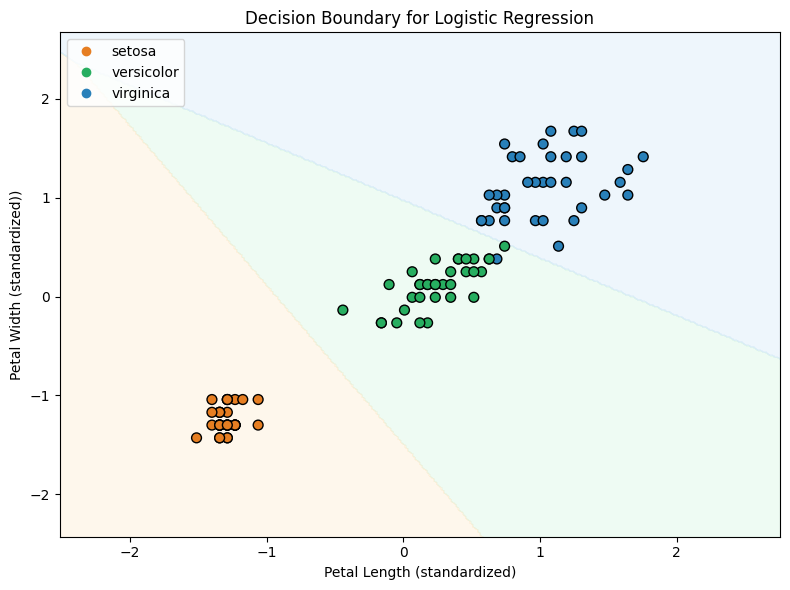

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 可視化のために 2 特徴量（petal length, petal width）に限定
X_vis = iris.data[:, 2:4]   # 特徴量 2, 3 のみ使用
y_vis = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

model_vis = LogisticRegression(
    C=1.0, solver='lbfgs',
    max_iter=200, random_state=42
)
model_vis.fit(X_tr_sc, y_tr)

# メッシュグリッドの生成
x_min, x_max = X_tr_sc[:, 0].min() - 1, X_tr_sc[:, 0].max() + 1
y_min, y_max = X_tr_sc[:, 1].min() - 1, X_tr_sc[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# プロット
fig, ax = plt.subplots(figsize=(8, 6))
cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
scatter = ax.scatter(
    X_tr_sc[:, 0], X_tr_sc[:, 1],
    c=y_tr, cmap=cmap_pt, edgecolors='k', s=50
)
ax.set_xlabel('Petal Length (standardized)')
ax.set_ylabel('Petal Width (standardized))')
ax.set_title('Decision Boundary for Logistic Regression')
ax.legend(
    handles=scatter.legend_elements()[0],
    labels=list(iris.target_names),
    loc='upper left'
)
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150)
plt.show()


## 正則化パラメータ C の影響を比較

In [8]:
from sklearn.model_selection import cross_val_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

print(f"{'C':>8s}  |  交差検証スコア (平均 ± 標準偏差)")
print("-" * 50)

for C in C_values:
    lr = LogisticRegression(
        C=C, solver='lbfgs',
        max_iter=500, random_state=42
    )
    scores = cross_val_score(lr, scaler.fit_transform(X), y, cv=5)
    print(f"{C:>8.3f}  |  {scores.mean():.4f} ± {scores.std():.4f}")

# C が小さい → 正則化が強い → 重みが小さく抑えられる（未学習の可能性）
# C が大きい → 正則化が弱い → 訓練データに適合しやすい（過学習の可能性）

       C  |  交差検証スコア (平均 ± 標準偏差)
--------------------------------------------------
   0.001  |  0.8200 ± 0.0806
   0.010  |  0.8600 ± 0.0712
   0.100  |  0.9267 ± 0.0573
   1.000  |  0.9600 ± 0.0389
  10.000  |  0.9733 ± 0.0327
 100.000  |  0.9733 ± 0.0327
